In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
import tensorflow as tf

# تنظیمات اولیه
DATA_DIR = '../data/human-and-non-human/training_set'
IMG_SIZE = 96
BATCH_SIZE = 32

# تابع نرمال‌سازی سریع
def process_data(image, label):
    return image / 255.0, label

# ۱. بارگذاری و آماده‌سازی داده‌های آموزشی
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)
train_dataset = train_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ۲. بارگذاری و آماده‌سازی داده‌های اعتبارسنجی
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)
val_dataset = val_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("متغیرهای داده با موفقیت در این نوتبوک ساخته شدند.")

Found 8017 files belonging to 2 classes.
Using 6414 files for training.
Found 8017 files belonging to 2 classes.
Using 1603 files for validation.
متغیرهای داده با موفقیت در این نوتبوک ساخته شدند.


In [8]:
model = models.Sequential([
    layers.InputLayer(input_shape=(96, 96, 1)),
    
    # لایه اول
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(), # اضافه شدن نرمال‌ساز
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # لایه دوم
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # لایه سوم
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    # لایه متراکم
    layers.Dense(16),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        36,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,689 (158.94 KB)

 Trainable params: 40,577 (158.50 KB)

 Non-trainable params: 112 (448.00 B)

In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy', # تابع خطای مخصوص مسائل دوکلاسه‌
              metrics=['accuracy'])

EPOCHS = 15

print("شروع فرآیند آموزش شبکه...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

شروع فرآیند آموزش شبکه...
Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9462 - loss: 0.2135 - val_accuracy: 0.5377 - val_loss: 0.6470
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9905 - loss: 0.0736 - val_accuracy: 0.9726 - val_loss: 0.1183
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9973 - loss: 0.0355 - val_accuracy: 0.9944 - val_loss: 0.0222
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9988 - loss: 0.0212 - val_accuracy: 0.9975 - val_loss: 0.0132
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.9998 - loss: 0.0127 - val_accuracy: 0.9963 - val_loss: 0.0123
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.9963 - val_loss: 0.0124
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9986 - loss: 0.0111 - val_accuracy: 0.9963 - val_loss: 0.0132
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9998

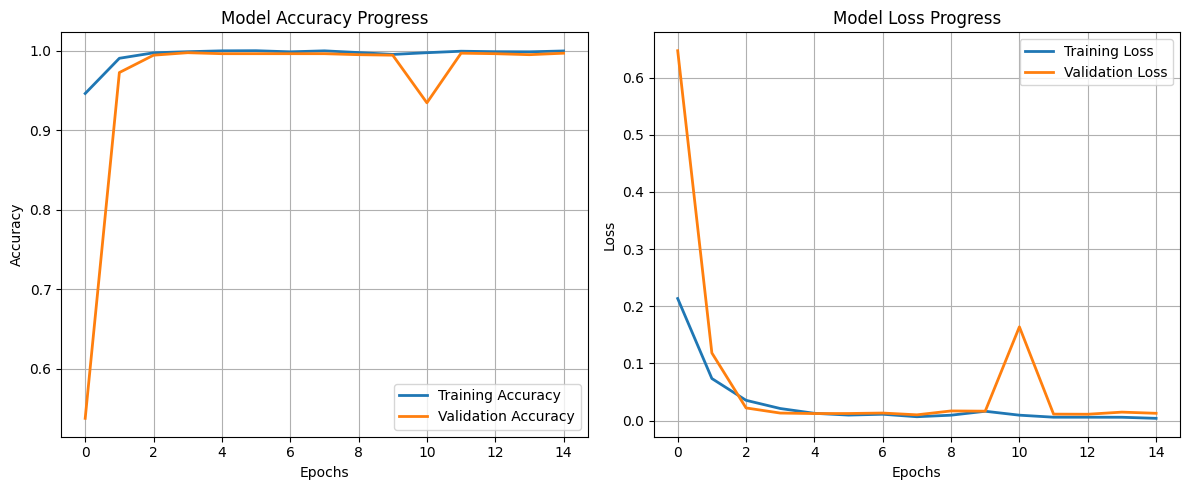

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# نمودار دقت (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# نمودار خطا (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
model.save('human_detection_base.keras')
print("مدل پایه با موفقیت ذخیره شد و آماده کوانتیزاسیون است.")

مدل پایه با موفقیت ذخیره شد و آماده کوانتیزاسیون است.
